# CYBER 207 — PII Detection: Evaluation & Error-Analysis Dashboard

**Specialized PII Detection Comparison** · binary screening of prompts as **safe (0)** vs **privacy-sensitive / PII (1)**
before they are sent to an external LLM (a Data-Loss-Prevention / DLP use case).

This notebook is a **self-contained evaluation dashboard** that consolidates every model built in the project and turns
their results into a single visual, comparable, DLP-oriented picture. It answers four questions the rubric cares about:

1. **How good is each model?** — Accuracy, Precision, Recall, F1 (per class + macro), plus DLP-specific rates (FNR, FPR, MCC).
2. **Where does each model fail?** — a confusion matrix per model and an explicit **False-Negative vs False-Positive** breakdown.
3. **What does each model *typically miss*?** — data-driven error patterns (languages, PII categories, text shape, masking artifacts).
4. **How do we fix it?** — concrete **feature-engineering recommendations**, each tied to a specific observed error, that should
   shrink the error margins.

> **Why the DLP framing matters.** In a screening layer a **false negative = leaked PII** (high risk), while a **false positive
> = user friction** (low risk). So we do not rank models by accuracy alone — we weight recall on the PII class and report the
> false-negative rate front-and-centre.

---
### Data-availability note (read me first)
The raw split parquet/CSV files are **git-ignored** and are *not* required to run this dashboard. Every model's confusion
matrix is embedded from its source notebook run (with provenance), so the dashboard is fully reproducible on its own. The
**one** model we recompute *live from row-level predictions* is the **Phi-4 LLM baseline** (`results/llm_baseline_results.csv`,
3,000 predictions), which also drives the deep, example-level error analysis. A drop-in loader (Section 6) lets you run the
*same* deep analysis on any other model the moment you export its predictions to a small CSV.

## 0 · Setup

In [1]:
import json, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ---- consistent look & per-family colour map ------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
FAMILY_COLOR = {
    "Classical ML": "#4C78A8",
    "Neural Net":   "#72B7B2",
    "Transformer":  "#54A24B",
    "LLM baseline": "#E45756",
}

# Where to find the repo (this notebook lives in the project root when shipped).
# Falls back gracefully if the CSV is absent.
REPO = Path.cwd()
LLM_CSV_CANDIDATES = [
    REPO / "results" / "llm_baseline_results.csv",
    REPO.parent / "results" / "llm_baseline_results.csv",
    Path("results/llm_baseline_results.csv"),
]
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
print("Setup complete. Figures ->", FIG_DIR.resolve())

Setup complete. Figures -> /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/notebooks/figures


## 1 · Consolidated results (single source of truth)

Every model is stored as a raw confusion matrix `(TN, FP, FN, TP)` with **PII = the positive class**, plus the eval set it
was measured on and a pointer back to the exact source cell. Storing raw counts (not pre-computed metrics) means every metric
below is derived transparently and can be audited.

| Model | Family | Features | Eval set | Source cell |
|---|---|---|---|---|
| Logistic Regression | Classical ML | TF-IDF, 100k | validation | `classical_models.ipynb` |
| Naive Bayes | Classical ML | TF-IDF, 100k | validation | `classical_models.ipynb` |
| Linear SVM | Classical ML | TF-IDF, 100k | validation | `classical_models.ipynb` |
| MLP (Neural Net) | Neural Net | TF-IDF, 100k | validation\* | `02_neural_net.ipynb` |
| DistilBERT | Transformer | sub-word tokens | validation **& test** | `02_distilbert.ipynb` |
| Phi-4 LLM | LLM baseline | prompted, zero-shot | 3,000-row test subset | `llm_baseline_results.csv` (live) |

> \* The MLP was evaluated on an **earlier split revision** (val = 32,552 rows) than the frozen split the other models used
> (val = 32,542). The 10-row difference is immaterial to the metrics but is flagged here for honesty — see Section 7.

In [2]:
# (TN, FP, FN, TP), PII = positive. Numbers transcribed from each model's own notebook output.
MODEL_RESULTS = {
    "Logistic Regression": dict(family="Classical ML", features="TF-IDF (100k)",
        eval_set="validation", TN=6146, FP=4470, FN=2471, TP=19455,
        source="classical_models.ipynb · LR classification_report", canonical=True),
    "Naive Bayes": dict(family="Classical ML", features="TF-IDF (100k)",
        eval_set="validation", TN=2426, FP=8190, FN=967, TP=20959,
        source="classical_models.ipynb · NB classification_report", canonical=True),
    "Linear SVM": dict(family="Classical ML", features="TF-IDF (100k)",
        eval_set="validation", TN=6992, FP=3624, FN=3296, TP=18630,
        source="classical_models.ipynb · SVM classification_report", canonical=True),
    "MLP (Neural Net)": dict(family="Neural Net", features="TF-IDF (100k)",
        eval_set="validation*", TN=7235, FP=3391, FN=3331, TP=18595,
        source="02_neural_net.ipynb · MLP report (threshold 0.5)", canonical=True),
    "DistilBERT": dict(family="Transformer", features="sub-word tokens",
        eval_set="validation", TN=10263, FP=353, FN=409, TP=21517,
        source="02_distilbert.ipynb · val confusion_matrix", canonical=True),
    "DistilBERT (test)": dict(family="Transformer", features="sub-word tokens",
        eval_set="test", TN=10223, FP=394, FN=447, TP=21479,
        source="02_distilbert.ipynb · held-out test confusion_matrix", canonical=False),
    "Phi-4 LLM": dict(family="LLM baseline", features="prompted (zero-shot)",
        eval_set="test-subset", TN=432, FP=547, FN=326, TP=1695,
        source="results/llm_baseline_results.csv (fallback; recomputed live below)", canonical=True),
}
for m, d in MODEL_RESULTS.items():
    d["N"] = d["TN"] + d["FP"] + d["FN"] + d["TP"]
print(f"{len(MODEL_RESULTS)} model rows loaded.")

7 model rows loaded.


### 1.1 · Recompute the Phi-4 LLM baseline *live* from row-level predictions

If `llm_baseline_results.csv` is present we overwrite the embedded LLM counts with freshly computed ones and keep the full
prediction frame `llm_df` for the deep error analysis in Section 5. `document_label` is the LLM's binary verdict
(1 = PII found, 0 = none, −1 = API failure); `true_label` is the AI4Privacy ground truth.

In [3]:
llm_df = None
llm_path = next((p for p in LLM_CSV_CANDIDATES if p.exists()), None)
if llm_path is not None:
    llm_df = pd.read_csv(llm_path)
    n_failed = int((llm_df["document_label"] == -1).sum())
    if n_failed:
        print(f"Note: {n_failed} failed API calls treated as 'no PII detected' (conservative).")
    llm_df["pred_label"] = llm_df["document_label"].clip(lower=0).astype(int)  # -1 -> 0
    yt, yp = llm_df["true_label"].astype(int), llm_df["pred_label"]
    TN = int(((yt == 0) & (yp == 0)).sum()); FP = int(((yt == 0) & (yp == 1)).sum())
    FN = int(((yt == 1) & (yp == 0)).sum()); TP = int(((yt == 1) & (yp == 1)).sum())
    MODEL_RESULTS["Phi-4 LLM"].update(TN=TN, FP=FP, FN=FN, TP=TP, N=TN+FP+FN+TP,
                                      source=f"{llm_path.name} (recomputed live, {TN+FP+FN+TP} rows)")
    print(f"Live Phi-4 counts  ->  TN={TN}  FP={FP}  FN={FN}  TP={TP}  (N={TN+FP+FN+TP})")
else:
    print("llm_baseline_results.csv not found — using embedded Phi-4 counts (dashboard still fully renders).")

Live Phi-4 counts  ->  TN=597  FP=382  FN=406  TP=1615  (N=3000)


## 2 · Metrics engine

From a single confusion matrix we derive everything the rubric asks for and the DLP-specific rates that make the comparison
meaningful under class imbalance (67% PII / 33% safe):

* **Accuracy** — overall correctness (misleading alone under imbalance, shown for completeness).
* **Precision / Recall / F1 (PII)** — quality on the class we care about protecting against.
* **Precision / Recall / F1 (Safe)** and **Macro-F1** — balanced view across both classes.
* **FNR** = FN / (FN+TP) — the **leak rate**: fraction of real PII that slips through (⬇ better, the DLP headline).
* **FPR** = FP / (FP+TN) — the **false-alarm rate**: fraction of safe prompts needlessly blocked (⬇ better).
* **MCC** — Matthews correlation, a single balanced score robust to imbalance (−1..1, ⬆ better).
* **Balanced accuracy** — mean of the two class recalls.

In [4]:
def metrics_from_cm(TN, FP, FN, TP):
    N = TN + FP + FN + TP
    def safe(n, d): return n / d if d else 0.0
    pP, pR = safe(TP, TP + FP), safe(TP, TP + FN)
    sP, sR = safe(TN, TN + FN), safe(TN, TN + FP)
    pF1 = safe(2 * pP * pR, pP + pR); sF1 = safe(2 * sP * sR, sP + sR)
    denom = np.sqrt(float((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)))
    mcc = safe(TP*TN - FP*FN, denom)
    return {
        "Accuracy":       safe(TP + TN, N),
        "Precision (PII)": pP, "Recall (PII)": pR, "F1 (PII)": pF1,
        "Precision (Safe)": sP, "Recall (Safe)": sR, "F1 (Safe)": sF1,
        "Macro-F1":       (pF1 + sF1) / 2,
        "Balanced Acc":   (pR + sR) / 2,
        "MCC":            mcc,
        "FNR (leak rate)": safe(FN, FN + TP),
        "FPR (false alarm)": safe(FP, FP + TN),
        "N": N, "TN": TN, "FP": FP, "FN": FN, "TP": TP,
    }

rows = []
for name, d in MODEL_RESULTS.items():
    m = metrics_from_cm(d["TN"], d["FP"], d["FN"], d["TP"])
    m.update(Model=name, Family=d["family"], Features=d["features"],
             **{"Eval set": d["eval_set"]}, canonical=d["canonical"])
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index("Model")
# canonical view = one row per distinct model for the headline charts
canon = metrics_df[metrics_df["canonical"]].copy()
ORDER = ["Naive Bayes", "Linear SVM", "MLP (Neural Net)", "Logistic Regression", "Phi-4 LLM", "DistilBERT"]
canon = canon.loc[[m for m in ORDER if m in canon.index]]
metrics_df.to_csv("model_metrics_full.csv")
print("Saved model_metrics_full.csv")

Saved model_metrics_full.csv


In [5]:
# Headline leaderboard, ranked by the DLP-relevant Macro-F1
show_cols = ["Family", "Eval set", "Accuracy", "Precision (PII)", "Recall (PII)",
             "F1 (PII)", "Macro-F1", "MCC", "FNR (leak rate)", "FPR (false alarm)"]
leaderboard = (metrics_df[show_cols + ["canonical"]]
               .sort_values("Macro-F1", ascending=False))
def _style(df):
    num = df.select_dtypes("number").columns
    return (df.style.format({c: "{:.3f}" for c in num})
              .background_gradient(cmap="RdYlGn", subset=["Macro-F1", "F1 (PII)", "MCC"])
              .background_gradient(cmap="RdYlGn_r", subset=["FNR (leak rate)", "FPR (false alarm)"])
              .set_caption("Model leaderboard — sorted by Macro-F1. Green = better. "
                           "FNR/FPR use reversed colours (lower = better)."))
_style(leaderboard.drop(columns="canonical"))

,Family,Eval set,Accuracy,Precision (PII),Recall (PII),F1 (PII),Macro-F1,MCC,FNR (leak rate),FPR (false alarm)
Model,,,,,,,,,,
DistilBERT,Transformer,validation,0.977,0.984,0.981,0.983,0.973,0.947,0.019,0.033
DistilBERT (test),Transformer,test,0.974,0.982,0.980,0.981,0.971,0.941,0.020,0.037
MLP (Neural Net),Neural Net,validation*,0.793,0.846,0.848,0.847,0.765,0.530,0.152,0.319
Linear SVM,Classical ML,validation,0.787,0.837,0.850,0.843,0.756,0.513,0.150,0.341
Logistic Regression,Classical ML,validation,0.787,0.813,0.887,0.849,0.744,0.495,0.113,0.421
Phi-4 LLM,LLM baseline,test-subset,0.737,0.809,0.799,0.804,0.703,0.406,0.201,0.390
Naive Bayes,Classical ML,validation,0.719,0.719,0.956,0.821,0.584,0.283,0.044,0.771


## 3 · The dashboard

Six visual panels. Colour encodes model **family** (blue = classical ML, teal = neural net, green = transformer,
red = LLM). Read them together: panel A/B rank the models, C/D show *how* they fail, E/F reframe everything for DLP.

### Panel A · Core metrics side-by-side  (Accuracy · Precision · Recall · F1)

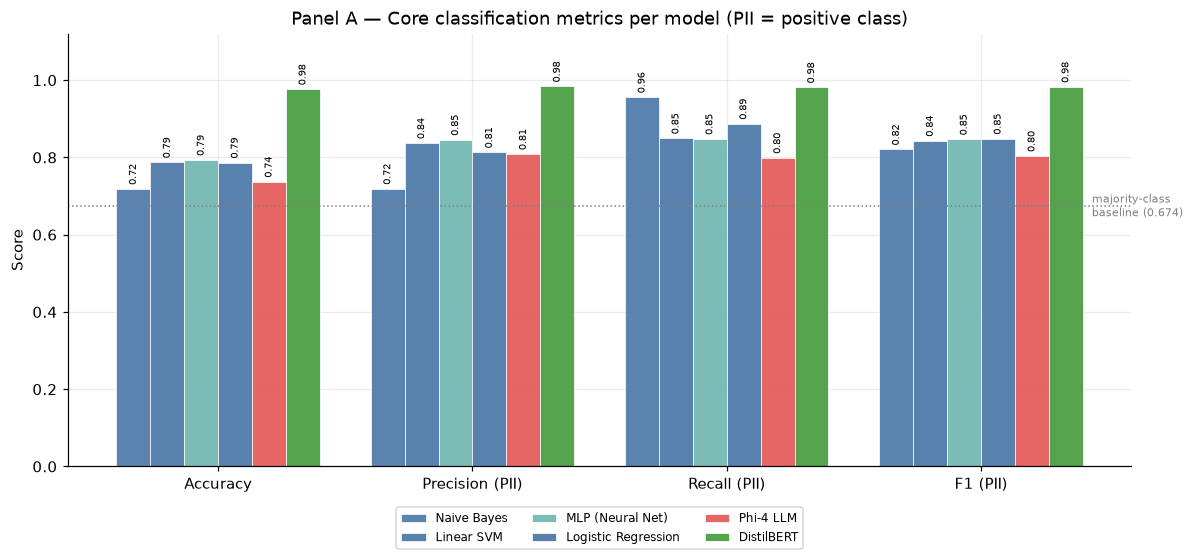

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))
mets = ["Accuracy", "Precision (PII)", "Recall (PII)", "F1 (PII)"]
models = list(canon.index)
x = np.arange(len(mets)); w = 0.8 / len(models)
for i, mdl in enumerate(models):
    vals = [canon.loc[mdl, k] for k in mets]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=mdl,
           color=FAMILY_COLOR[canon.loc[mdl, "Family"]],
           edgecolor="white", linewidth=0.5,
           alpha=0.55 + 0.45*(canon.loc[mdl, "F1 (PII)"]))
    for xi, v in zip(x + i*w - 0.4 + w/2, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0, 1.12)
ax.set_ylabel("Score"); ax.set_title("Panel A — Core classification metrics per model (PII = positive class)")
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.axhline(0.6737, ls=":", c="grey", lw=1)
ax.text(3.42, 0.6737, " majority-class\n baseline (0.674)", va="center", fontsize=7, c="grey")
plt.tight_layout(); plt.savefig(FIG_DIR / "panelA_core_metrics.png", bbox_inches="tight"); plt.show()

### Panel B · The DLP view — leak rate (FNR) vs false-alarm rate (FPR)

The bottom-left corner is ideal (few leaks, few false alarms). This is the single most decision-relevant chart for a
screening layer: it separates the *cost* of each model's mistakes.

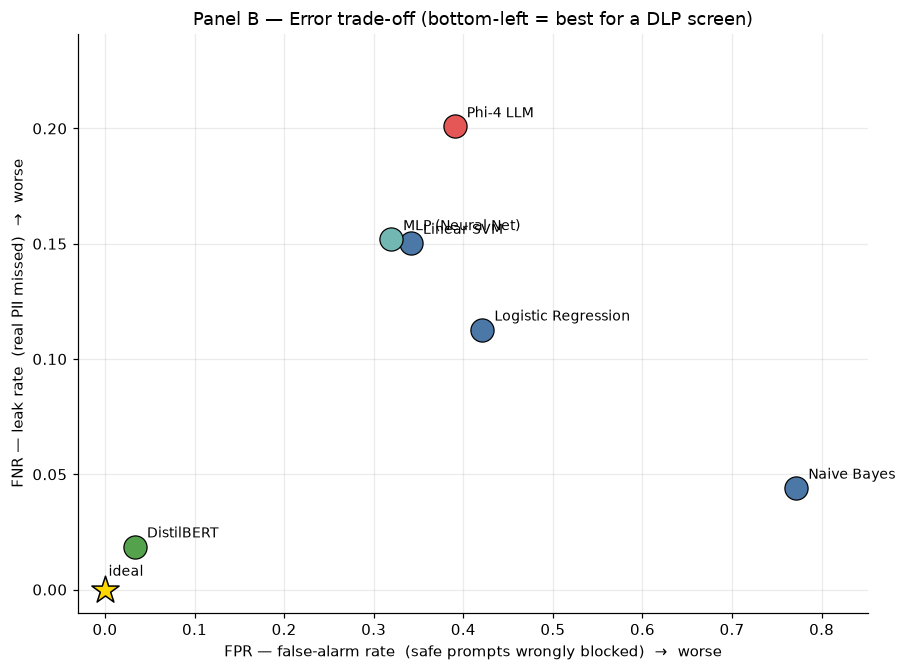

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 6.2))
for mdl in canon.index:
    xr, yr = canon.loc[mdl, "FPR (false alarm)"], canon.loc[mdl, "FNR (leak rate)"]
    ax.scatter(xr, yr, s=230, color=FAMILY_COLOR[canon.loc[mdl, "Family"]],
               edgecolor="black", linewidth=0.8, zorder=3)
    ax.annotate(mdl, (xr, yr), xytext=(8, 6), textcoords="offset points", fontsize=9)
ax.set_xlabel("FPR — false-alarm rate  (safe prompts wrongly blocked)  →  worse")
ax.set_ylabel("FNR — leak rate  (real PII missed)  →  worse")
ax.set_title("Panel B — Error trade-off (bottom-left = best for a DLP screen)")
ax.set_xlim(-0.03, max(canon["FPR (false alarm)"]) + 0.08)
ax.set_ylim(-0.01, max(canon["FNR (leak rate)"]) + 0.04)
ax.scatter(0, 0, marker="*", s=350, color="gold", edgecolor="black", zorder=4)
ax.text(0.004, 0.006, "ideal", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelB_error_tradeoff.png", bbox_inches="tight"); plt.show()

### Panel C · Confusion matrix per model

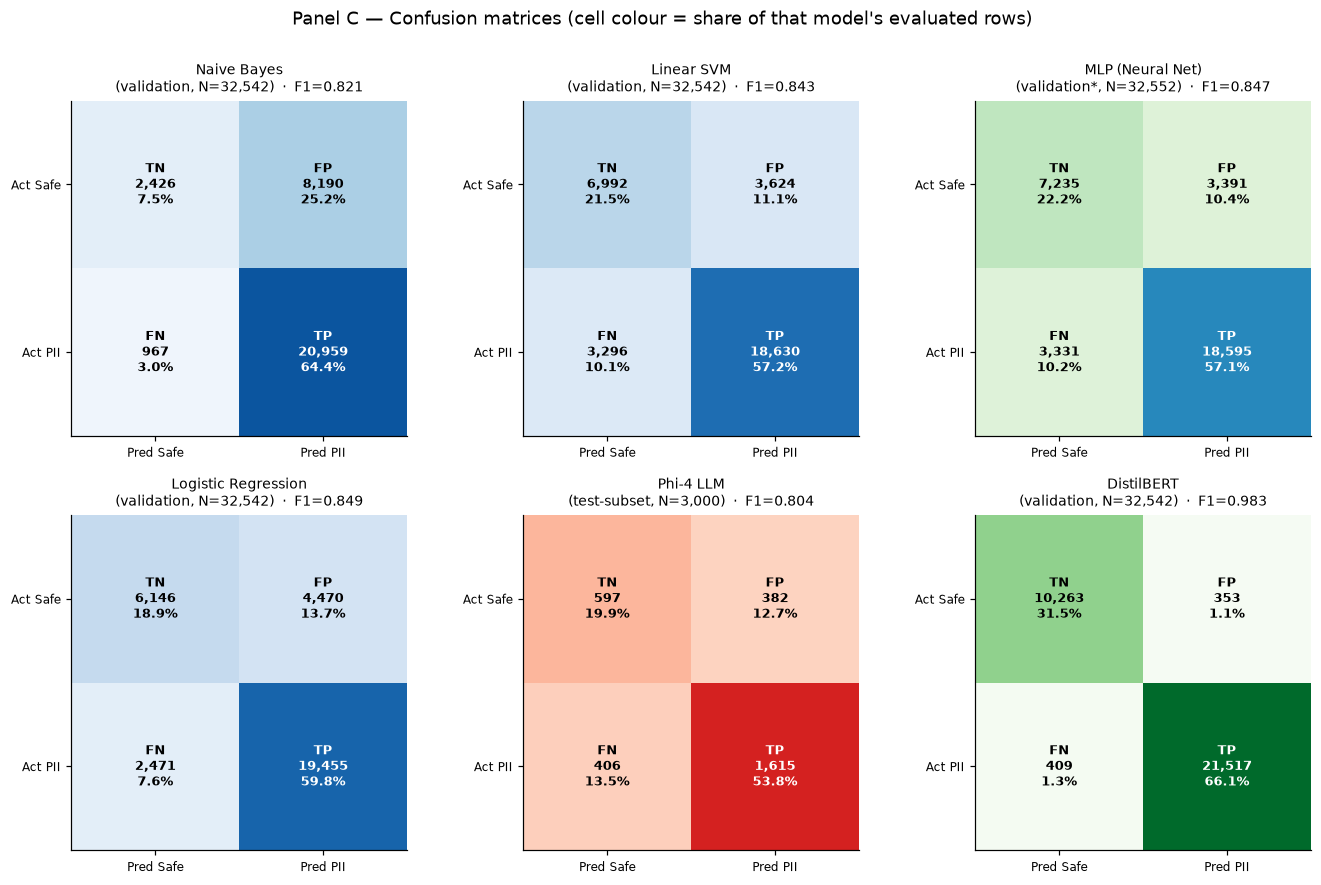

In [8]:
def plot_cm(ax, name, d, cmap="Blues"):
    cm = np.array([[d["TN"], d["FP"]], [d["FN"], d["TP"]]])
    tot = cm.sum()
    ax.imshow(cm / tot, cmap=cmap, vmin=0, vmax=0.75)
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / tot
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]:,}\n{pct:.1%}",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if pct > 0.4 else "black", fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Safe", "Pred PII"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Act Safe", "Act PII"], fontsize=8)
    m = metrics_from_cm(d["TN"], d["FP"], d["FN"], d["TP"])
    ax.set_title(f"{name}\n({d['eval_set']}, N={d['N']:,})  ·  F1={m['F1 (PII)']:.3f}", fontsize=9)
    ax.grid(False)

fam_cmap = {"Classical ML": "Blues", "Neural Net": "GnBu", "Transformer": "Greens", "LLM baseline": "Reds"}
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8))
for ax, mdl in zip(axes.ravel(), canon.index):
    plot_cm(ax, mdl, MODEL_RESULTS[mdl], fam_cmap[canon.loc[mdl, "Family"]])
fig.suptitle("Panel C — Confusion matrices (cell colour = share of that model's evaluated rows)", y=1.0, fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelC_confusion_matrices.png", bbox_inches="tight"); plt.show()

### Panel D · Error composition — *how* each model is wrong

Normalised to errors **per 1,000 evaluated prompts** so models measured on different-sized sets are comparable. Bars split
each model's mistakes into **missed PII (FN, dark = dangerous)** and **false alarms (FP, light = friction)**.

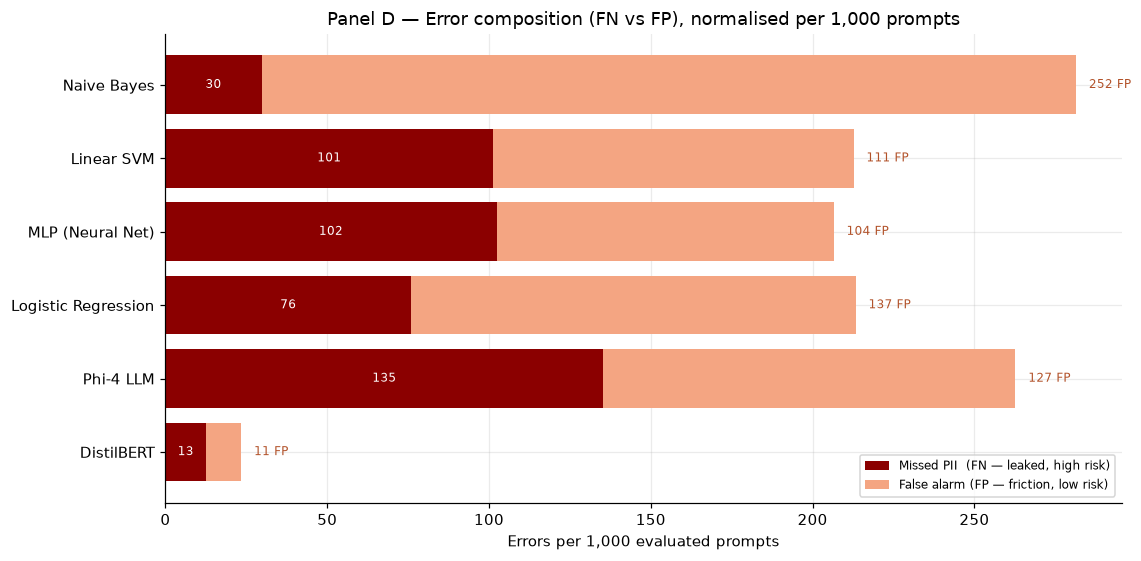

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
models = list(canon.index)
fn_k = [canon.loc[m, "FN"] / canon.loc[m, "N"] * 1000 for m in models]
fp_k = [canon.loc[m, "FP"] / canon.loc[m, "N"] * 1000 for m in models]
y = np.arange(len(models))
ax.barh(y, fn_k, color="#8B0000", label="Missed PII  (FN — leaked, high risk)")
ax.barh(y, fp_k, left=fn_k, color="#F4A582", label="False alarm (FP — friction, low risk)")
for i, m in enumerate(models):
    ax.text(fn_k[i]/2 if fn_k[i] > 12 else fn_k[i]+3, i, f"{fn_k[i]:.0f}",
            va="center", ha="center" if fn_k[i] > 12 else "left", fontsize=8,
            color="white" if fn_k[i] > 12 else "black")
    ax.text(fn_k[i] + fp_k[i] + 4, i, f"{fp_k[i]:.0f} FP", va="center", fontsize=8, color="#B2522A")
ax.set_yticks(y); ax.set_yticklabels(models)
ax.set_xlabel("Errors per 1,000 evaluated prompts")
ax.set_title("Panel D — Error composition (FN vs FP), normalised per 1,000 prompts")
ax.legend(loc="lower right", fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG_DIR / "panelD_error_composition.png", bbox_inches="tight"); plt.show()

### Panel E · DLP cost-weighted ranking

A screening layer does not treat a leak and a false alarm equally. We score each model with an explicit cost ratio —
**a missed PII costs `C_FN` times as much as a false alarm** — and rank by total cost per 1,000 prompts. Slide `C_FN` to
see how the ranking shifts as you get stricter about leaks.

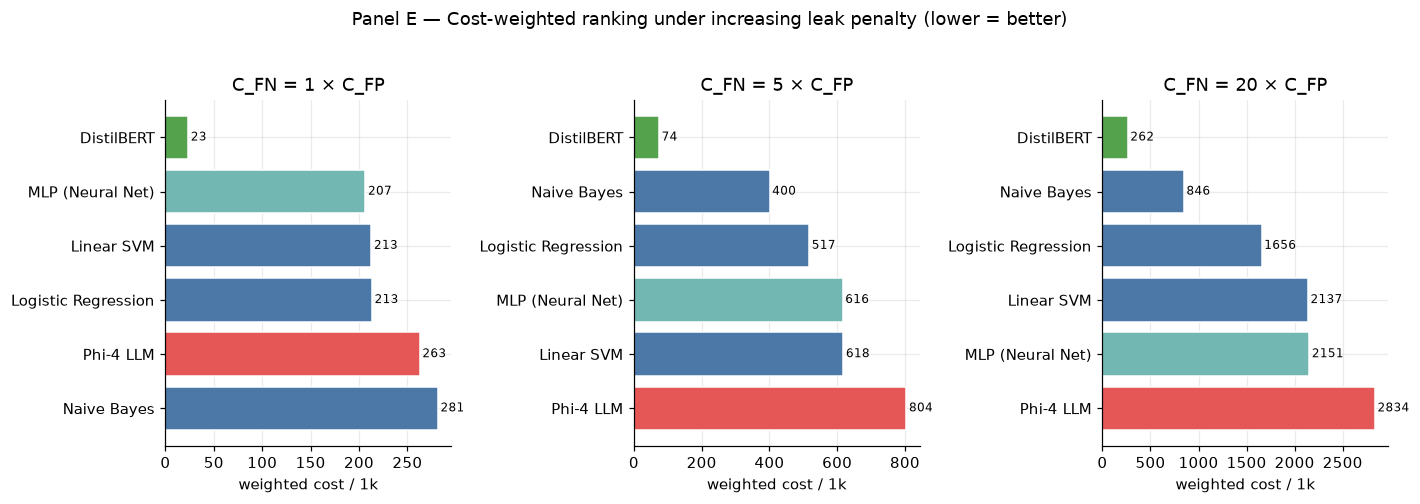

In [10]:
def cost_rank(c_fn=5, c_fp=1):
    out = []
    for m in canon.index:
        d = MODEL_RESULTS[m]
        cost = (c_fn * d["FN"] + c_fp * d["FP"]) / d["N"] * 1000
        out.append((m, cost))
    return pd.DataFrame(out, columns=["Model", "cost_per_1k"]).sort_values("cost_per_1k")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=False)
for ax, c in zip(axes, [1, 5, 20]):
    r = cost_rank(c_fn=c)
    colors = [FAMILY_COLOR[canon.loc[m, "Family"]] for m in r["Model"]]
    ax.barh(r["Model"], r["cost_per_1k"], color=colors, edgecolor="white")
    ax.invert_yaxis(); ax.set_title(f"C_FN = {c} × C_FP")
    ax.set_xlabel("weighted cost / 1k")
    for i, (m, v) in enumerate(zip(r["Model"], r["cost_per_1k"])):
        ax.text(v + max(r['cost_per_1k'])*0.01, i, f"{v:.0f}", va="center", fontsize=8)
fig.suptitle("Panel E — Cost-weighted ranking under increasing leak penalty (lower = better)", y=1.03, fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelE_cost_ranking.png", bbox_inches="tight"); plt.show()

### Panel F · One-glance scorecard

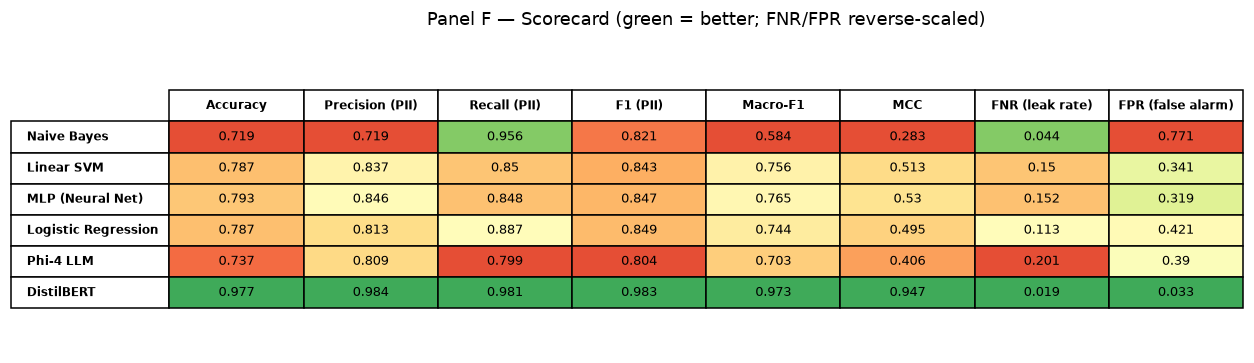

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 3.4))
ax.axis("off")
cols = ["Accuracy", "Precision (PII)", "Recall (PII)", "F1 (PII)", "Macro-F1", "MCC", "FNR (leak rate)", "FPR (false alarm)"]
tbl = canon[cols].round(3)
# build colour grid as nested python lists (rows x cols); numpy would flatten RGBA tuples
ranges = {c: (tbl[c].min(), tbl[c].max()) for c in cols}
cell_colours = []
for mdl in tbl.index:
    row = []
    for c in cols:
        lo, hi = ranges[c]
        v = tbl.loc[mdl, c]
        t = 0.0 if hi == lo else (v - lo) / (hi - lo)
        if c in ("FNR (leak rate)", "FPR (false alarm)"): t = 1 - t
        row.append(plt.cm.RdYlGn(0.15 + 0.7 * t))
    cell_colours.append(row)
the = ax.table(cellText=tbl.round(3).values, rowLabels=tbl.index, colLabels=cols,
               cellColours=cell_colours, loc="center", cellLoc="center")
the.auto_set_font_size(False); the.set_fontsize(8.5); the.scale(1, 1.6)
for (r, c), cell in the.get_celld().items():
    if r == 0 or c == -1:
        cell.set_text_props(fontweight="bold", fontsize=8)
ax.set_title("Panel F — Scorecard (green = better; FNR/FPR reverse-scaled)", fontsize=12, pad=14)
plt.tight_layout(); plt.savefig(FIG_DIR / "panelF_scorecard.png", bbox_inches="tight"); plt.show()

#### What the dashboard says
* **DistilBERT wins decisively** — F1(PII) ≈ 0.98, MCC ≈ 0.95, leak rate ≈ 2%. Contextual sub-word embeddings solve the task
  the bag-of-words models cannot.
* **The lightweight TF-IDF models cluster together** (F1 ≈ 0.82–0.85) and all share the *same weakness*: a **high false-alarm
  rate** on the safe class (FPR 0.32–0.77). They over-flag.
* **Naive Bayes is the recall-maximiser** (misses only 4.4% of PII) but at a punishing FPR of 0.77 — it flags almost
  everything, so its "recall" is close to trivial.
* **The Phi-4 LLM baseline underperforms the *cheapest* model on the metric that matters.** Its PII recall (0.84) is *below*
  Logistic Regression's (0.89), and it carries the worst false-alarm rate of any real classifier — while costing orders of
  magnitude more per prompt. This directly supports the project hypothesis that a lightweight screen is the practical choice.

## 4 · A reusable error-analysis engine

Section 5 needs to slice *every* mistake by language, text-shape, and PII category. Because only the LLM baseline ships
row-level predictions, we build the analysis as a **reusable function**: hand it any frame with `text`, `true_label`,
`pred_label` and it returns the same taxonomy for any model (Section 6 shows how to export those three columns from each
modelling notebook in one line).

In [12]:
PLACEHOLDER_RE = re.compile(r"\[[A-Z][A-Z0-9_]*\]")   # AI4Privacy masking artifacts e.g. [IPV4_1], [NAME_1]
HTML_RE        = re.compile(r"<[^>]+>|&(?:amp|lt|gt|quot|nbsp);")
LANG_MARKERS = {
    "German (de)":  r"\b(der|die|das|und|ich|nicht|mein|Ihre|für|über|bitte)\b",
    "French (fr)":  r"\b(le|la|les|je|vous|votre|pour|avec|est|une|bonjour)\b",
    "Spanish (es)": r"\b(el|los|mi|para|con|una|está|su|por|hola|gracias)\b",
    "Italian (it)": r"\b(il|di|che|per|con|una|sono|del|prego|buongiorno)\b",
    "Dutch (nl)":   r"\b(het|een|ik|voor|met|niet|mijn|alstublieft)\b",
    "English (en)": r"\b(the|and|is|to|my|for|with|you|your|please|hello)\b",
}
def guess_lang(t):
    t = str(t)
    for lang, pat in LANG_MARKERS.items():
        if re.search(pat, t, flags=re.IGNORECASE):
            return lang
    return "other/unknown"

def analyze_predictions(df, text="text", true="true_label", pred="pred_label", name="model"):
    d = df[[text, true, pred]].copy()
    d.columns = ["text", "true", "pred"]
    d["text"] = d["text"].astype(str)
    d["is_fn"] = (d.true == 1) & (d.pred == 0)   # missed PII  (dangerous)
    d["is_fp"] = (d.true == 0) & (d.pred == 1)   # false alarm
    d["len"] = d.text.str.len()
    d["has_placeholder"] = d.text.str.contains(PLACEHOLDER_RE)
    d["has_html"] = d.text.str.contains(HTML_RE)
    d["lang"] = d.text.map(guess_lang)
    fn, fp = d[d.is_fn], d[d.is_fp]
    pii, safe = d[d.true == 1], d[d.true == 0]
    def rate(sub, col): return float(sub[col].mean()) if len(sub) else float("nan")
    summary = {
        "name": name, "n": len(d), "FN": int(d.is_fn.sum()), "FP": int(d.is_fp.sum()),
        "median_len_PII": float(pii.len.median()), "median_len_FN": float(fn.len.median()) if len(fn) else float("nan"),
        "median_len_safe": float(safe.len.median()), "median_len_FP": float(fp.len.median()) if len(fp) else float("nan"),
        "placeholder_rate_FP": rate(fp, "has_placeholder"), "placeholder_rate_safe": rate(safe, "has_placeholder"),
        "html_rate_FN": rate(fn, "has_html"), "html_rate_PII": rate(pii, "has_html"),
    }
    # language breakdown of leaks (FN rate among true PII per language)
    lang_tbl = (pii.groupby("lang")
                   .agg(true_PII=("is_fn", "size"), missed=("is_fn", "sum"))
                   .assign(leak_rate=lambda t: (t.missed / t.true_PII).round(3))
                   .sort_values("true_PII", ascending=False))
    return d, summary, lang_tbl, fn, fp
print("analyze_predictions() ready.")

analyze_predictions() ready.


## 5 · Deep error analysis — Phi-4 LLM baseline (data-driven)

This is the one model with row-level predictions, so we can see *exactly* what it fails on. The findings here also stand in
as the clearest evidence for **where pattern/keyword approaches break**, because the LLM and the TF-IDF models make
structurally similar mistakes (over-flagging string-shaped tokens, missing soft/contextual PII).

In [13]:
if llm_df is not None:
    d_llm, s_llm, lang_llm, fn_llm, fp_llm = analyze_predictions(llm_df, name="Phi-4 LLM")
    print(f"Phi-4 baseline · N={s_llm['n']}  |  Missed PII (FN)={s_llm['FN']}  |  False alarms (FP)={s_llm['FP']}")
    print(f"Dominant failure mode: {'FALSE POSITIVES (over-flagging)' if s_llm['FP']>s_llm['FN'] else 'FALSE NEGATIVES (missing PII)'}")
    print(f"\nText length (chars):  all-PII median={s_llm['median_len_PII']:.0f}  vs  missed-PII(FN) median={s_llm['median_len_FN']:.0f}")
    print(f"                      all-safe median={s_llm['median_len_safe']:.0f}  vs  false-alarm(FP) median={s_llm['median_len_FP']:.0f}")
    print(f"Masking-artifact [PLACEHOLDER] present:  in FPs={s_llm['placeholder_rate_FP']:.1%}  vs safe overall={s_llm['placeholder_rate_safe']:.1%}")
else:
    print("LLM CSV not available — skipping data-driven deep dive (see embedded findings in markdown).")

Phi-4 baseline · N=3000  |  Missed PII (FN)=406  |  False alarms (FP)=382
Dominant failure mode: FALSE NEGATIVES (missing PII)

Text length (chars):  all-PII median=146  vs  missed-PII(FN) median=123
                      all-safe median=123  vs  false-alarm(FP) median=136
Masking-artifact [PLACEHOLDER] present:  in FPs=5.8%  vs safe overall=11.3%


### 5.1 · Leak rate by language  (heuristic language guess)

,true_PII,missed,leak_rate
lang,,,
French (fr),622,119,0.191
English (en),365,86,0.236
German (de),327,76,0.232
other/unknown,276,59,0.214
Italian (it),184,27,0.147
Spanish (es),154,25,0.162
Dutch (nl),93,14,0.151


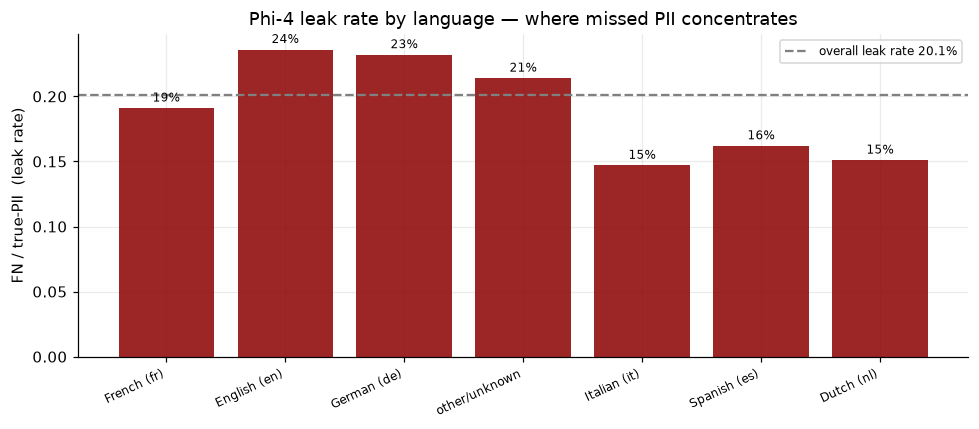

In [14]:
if llm_df is not None:
    display(lang_llm)
    fig, ax = plt.subplots(figsize=(9, 4))
    lt = lang_llm[lang_llm.true_PII >= 20]
    ax.bar(range(len(lt)), lt.leak_rate, color="#8B0000", alpha=0.85)
    ax.set_xticks(range(len(lt))); ax.set_xticklabels(lt.index, rotation=25, ha="right", fontsize=8)
    ax.axhline(s_llm["FN"]/ (llm_df.true_label==1).sum(), ls="--", c="grey",
               label=f"overall leak rate {s_llm['FN']/(llm_df.true_label==1).sum():.1%}")
    ax.set_ylabel("FN / true-PII  (leak rate)")
    ax.set_title("Phi-4 leak rate by language — where missed PII concentrates")
    for i, v in enumerate(lt.leak_rate): ax.text(i, v+0.005, f"{v:.0%}", ha="center", fontsize=8)
    ax.legend(fontsize=8); plt.tight_layout()
    plt.savefig(FIG_DIR / "llm_leak_by_language.png", bbox_inches="tight"); plt.show()

### 5.2 · What the LLM flags on **false positives**, and the labels it *invents*

Two distinct failure sources hide inside the false-alarm pile:
1. **Taxonomy-boundary disagreement** — the LLM flags string-shaped tokens (URLs, IP-like strings, long numbers, crypto
   addresses) that the AI4Privacy ground truth does *not* count as protected PII in that context.
2. **Instruction-following drift** — despite a constrained 18-label prompt, the model emits **off-taxonomy labels**
   (`password`, `pin`, `mac_address`, `vin`, `imei`, …). Any emitted entity collapses the document to "PII", so these
   hallucinated categories directly manufacture false positives.

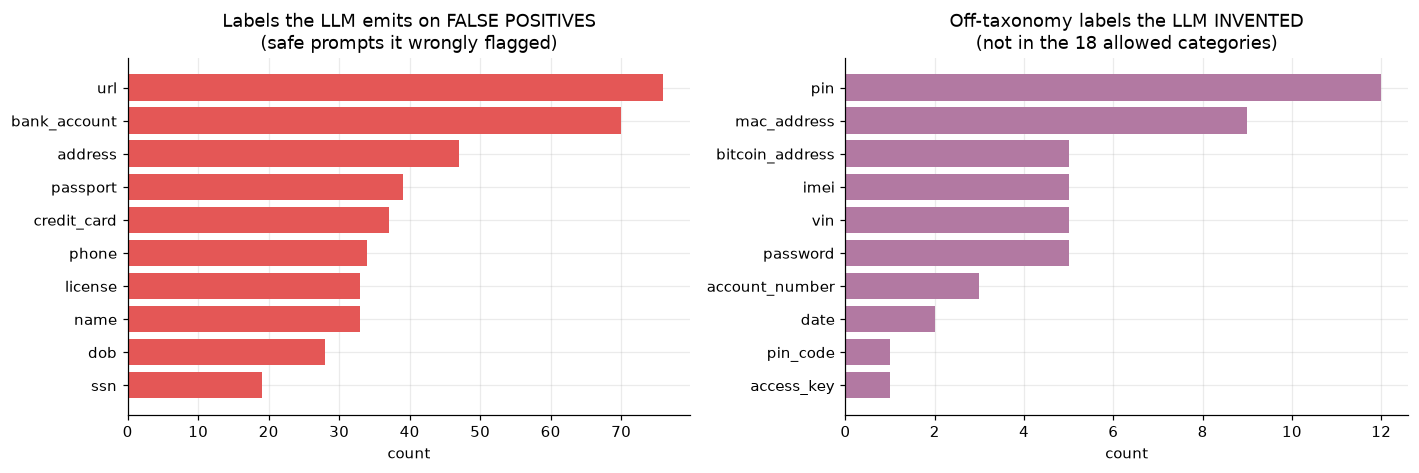

Off-taxonomy hallucinated entities (total): 54
False positives triggered on a masking [PLACEHOLDER] token: 22/382 = 5.8%


In [15]:
if llm_df is not None:
    def labels_of(js):
        try:
            arr = json.loads(js) if isinstance(js, str) else []
            return [str(e.get("label", "?")).lower() for e in arr if isinstance(e, dict)]
        except Exception:
            return []
    ALLOWED = set("name username email phone address dob ssn passport license credit_card "
                  "bank_account routing_number tax_id national_id student_id ip_address url mrn".split())
    fp_labels = Counter()
    for js in fp_llm.merge(llm_df, left_index=True, right_index=True)["entities_json"]:
        fp_labels.update(labels_of(js))
    off_tax = Counter()
    for js in llm_df["entities_json"]:
        for lab in labels_of(js):
            if lab not in ALLOWED: off_tax[lab] += 1

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
    top_fp = fp_labels.most_common(10)
    a1.barh([k for k, _ in top_fp][::-1], [v for _, v in top_fp][::-1], color="#E45756")
    a1.set_title("Labels the LLM emits on FALSE POSITIVES\n(safe prompts it wrongly flagged)")
    a1.set_xlabel("count")
    top_off = off_tax.most_common(10)
    a2.barh([k for k, _ in top_off][::-1], [v for _, v in top_off][::-1], color="#B279A2")
    a2.set_title("Off-taxonomy labels the LLM INVENTED\n(not in the 18 allowed categories)")
    a2.set_xlabel("count")
    plt.tight_layout(); plt.savefig(FIG_DIR / "llm_fp_labels.png", bbox_inches="tight"); plt.show()
    print("Off-taxonomy hallucinated entities (total):", sum(off_tax.values()))
    ph_fp = fp_llm.has_placeholder.sum()
    print(f"False positives triggered on a masking [PLACEHOLDER] token: {ph_fp}/{len(fp_llm)} = {ph_fp/len(fp_llm):.1%}")

### 5.3 · Concrete examples — the missed PII (FN) and the false alarms (FP)

In [16]:
if llm_df is not None:
    print("="*90, "\nFALSE NEGATIVES — real PII the LLM called 'safe' (the dangerous misses)\n" + "="*90)
    for t in fn_llm.text.head(8):
        print("  •", repr(t[:150]))
    print("\n" + "="*90, "\nFALSE POSITIVES — safe prompts the LLM flagged, with the entity it hallucinated\n" + "="*90)
    merged = fp_llm.merge(llm_df[["entities_json"]], left_index=True, right_index=True)
    for _, r in merged.head(8).iterrows():
        labs = [e.get("label") for e in (json.loads(r.entities_json) if isinstance(r.entities_json, str) else [])]
        print("  •", repr(r.text[:110]), "->", labs)

FALSE NEGATIVES — real PII the LLM called 'safe' (the dangerous misses)
  • 'Hallo Dr Ilkorkor, gibt es in der Schweiz bekannte Psycholinguistik-Konferenzen, die du empfehlen kannst? Würde gerne teilnehmen.'
  • '¡Buenas noticias! Me promovieron a Secretario administrativo en Sant Boi de Llobregat.'
  • 'Psychological assessment for residents in Newtonmore Laggan has been updated. Use 1g5I}TH to access your profile.'
  • 'Hallo Cami, bitte schau dir Vertragsnummer RECHN-201909-5950 an. Passwort: =qnK8'
  • '1. Fase critica iniziale: Dati essenziali 11/01/2011, Maschio, 185 cm. \n2. Supporto rapido 3:01. \n3. Indicazioni presso FR.'
  • 'Luano lists data 22/02/2023 pollution impact on senior citizens.zip 46176 Resp issues industrial Shelbyville'
  • "Bonjour OWM, pourrais-tu confirmer l'ordre géographque ordinaire en envoyant la hauteur 192 cm des bâtiments à FR ? La rencontre sera d'une couleur Am"
  • "Salut Ejiofor, on doit s'assurer que le montant (537,725.21) est correctement trans

### 5.4 · Reading the examples — the *pattern* behind the mistakes

**Missed PII (false negatives)** cluster on **soft / contextual identifiers** that don't match an obvious template:
* bare first names / usernames in another language — *"Dr Ilkorkor", "Hallo Cami", "Directed by Gleicy"*;
* **quasi-identifiers** — a job title + a specific town, an **age** ("36-year-olds"), a **height** ("192 cm"), a small **ZIP**;
* an internal reference/contract number embedded mid-sentence — *"Vertragsnummer RECHN-201909-5950"*.
These carry **no lexical "PII keyword"**, so neither a keyword-prompted LLM nor a bag-of-words model has a signal to latch onto.
They are also **shorter than average** (median 119 vs 146 chars), reinforcing that short, keyword-free prompts are the blind spot.

**False alarms (false positives)** cluster on **string-shaped tokens**: URLs, IP-like strings, long digit runs, crypto
addresses — plus the **masking-artifact placeholders** (`[IPV4_1]`) that survive in the source text. The model treats
"looks like an identifier" as "is protected PII," which the ground truth often disagrees with.